---
title: Method of Moments
---

## Data-informed priors via moment matching

A common challenge in Bayesian inference with SVGD is choosing sensible prior distributions. A vague prior may lead to slow convergence or poor exploration of the posterior, while an overly tight prior can bias the result. The `method_of_moments` method provides a principled way to construct data-informed priors by finding parameter estimates that match the model's theoretical moments to the empirical moments of the observed data.

The method solves the nonlinear least-squares problem:

$$
\hat{\theta}_{\text{MoM}} = \arg\min_{\theta > 0} \left\| \mathbf{m}(\theta) - \hat{\mathbf{m}} \right\|^2
$$

where $\mathbf{m}(\theta)$ are the model moments and $\hat{\mathbf{m}}$ are the sample moments computed from the data. The standard error of the estimator is obtained via the delta method:

$$
\text{Cov}(\hat\theta) \;=\; \left(\frac{\partial \mathbf{m}}{\partial \theta}\right)^{-1} \text{Cov}(\hat{\mathbf{m}}) \left(\frac{\partial \mathbf{m}}{\partial \theta}\right)^{-T}
$$

where $\text{Cov}(\hat{\mathbf{m}})$ is estimated from the data. The point estimate and standard error are then used to construct Gaussian priors centred on the MoM estimate.

This is fast (seconds, not minutes) and gives SVGD a much better starting point than a generic prior.

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, MoMResult, ProbMatchResult,
    Adam, ExpStepSize, clear_caches, dense_to_sparse,
    StateIndexer, Property,
) # ALWAYS import phasic first to set jax backend correctly
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
np.random.seed(42)
try:
    from vscodenb import set_vscode_theme
    set_vscode_theme()
except ImportError:
    pass
sns.set_palette('tab10')

## Single-parameter model

We start with the simplest case: a single-parameter exponential model. The coalescent rate $\theta$ governs how quickly lineages coalesce. For an exponential distribution, the method of moments has an analytical solution: $\hat{\theta} = 1 / \bar{x}$.

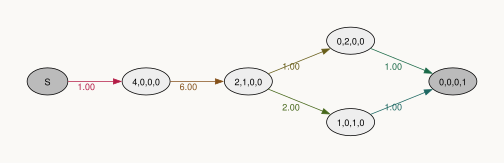

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

Sample observed data from the model with a known true parameter value:

In [3]:
true_theta = [7]
graph.update_weights(true_theta)
observed_data = graph.sample(1000)

Run method of moments to find the parameter estimate:

In [4]:
mom = graph.method_of_moments(observed_data)

The result is a `MoMResult` dataclass containing the estimate, standard errors, and ready-to-use priors:

In [5]:
print(f"True theta:     {true_theta}")
print(f"MoM estimate:   {mom.theta}")
print(f"Std error:      {mom.std}")
print(f"Converged:      {mom.success}")
print(f"Residual:       {mom.residual:.2e}")

True theta:     [7]
MoM estimate:   [7.2751936]
Std error:      [0.15985594]
Converged:      True
Residual:       1.08e+00


The `MoMResult` also reports how well the model moments match the sample moments:

In [6]:
print(f"Sample moments: {mom.sample_moments}")
print(f"Model moments:  {mom.model_moments}")

Sample moments: [[0.20624705 0.06304546]]
Model moments:  [0.20618008 0.06402775]


## Multi-parameter model

Method of moments is especially useful for multi-parameter models where choosing good priors by hand is difficult. Here we use a two-population island model with coalescent rate $\theta_0$ and migration rate $\theta_1$.

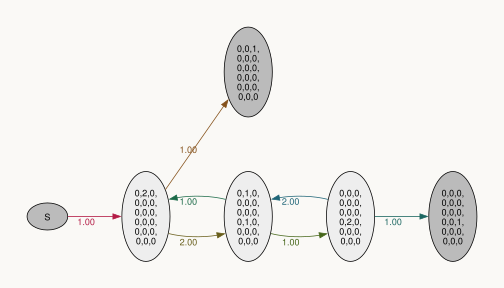

In [7]:
from phasic import StateIndexer, Property

nr_samples = 2

indexer = StateIndexer(
    descendants=[
    Property('pop1', min_value=0, max_value=nr_samples),
    Property('pop2', min_value=0, max_value=nr_samples),
    Property('in_pop', min_value=1, max_value=2),
])

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def coalescent_islands(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop:
                continue
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, pop2=des_pop2, in_pop=props_i.in_pop)
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)
            child[k] += 1
            transitions.append([child, [0, state[i]]])
    return transitions

graph = Graph(coalescent_islands)
graph.plot()

In [8]:
true_theta = [0.7, 0.9]
graph.update_weights(true_theta)
observed_data = graph.sample(1000)

Run method of moments on the two-parameter model:

In [9]:
mom = graph.method_of_moments(observed_data)

In [10]:
print(f"True theta:     {true_theta}")
print(f"MoM estimate:   {mom.theta}")
print(f"Std error:      {mom.std}")
print(f"Converged:      {mom.success}")

True theta:     [0.7, 0.9]
MoM estimate:   [0.70679884 0.76016923]
Std error:      [0.02482546 0.20611669]
Converged:      True


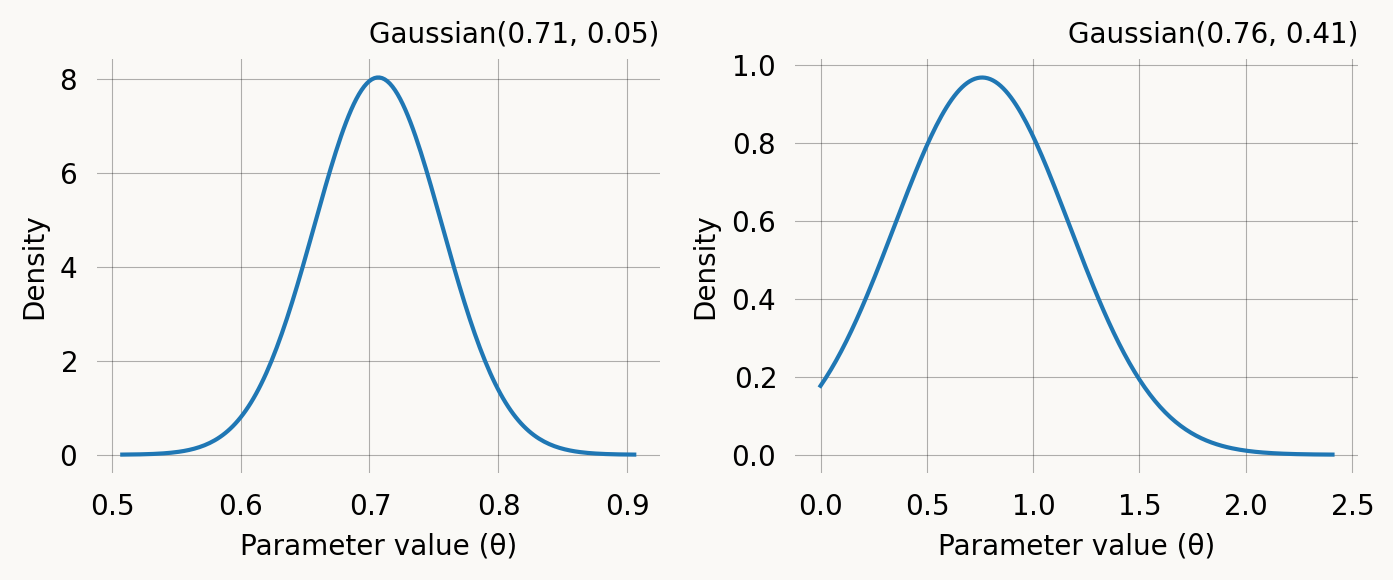

In [11]:
fig, axes = plt.subplots(1, len(mom.prior), figsize=(7,3))
for i, prior in enumerate(mom.prior):
    prior.plot(return_ax=True, ax=axes[i])
plt.tight_layout() ;

Use the MoM priors for SVGD inference:

In [12]:
svgd = graph.svgd(
    observed_data,
    prior=mom.prior,
    # optimizer=Adam(0.25),
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=20.0),
)

In [13]:
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         0.7076     0.6903     0.0639     0.6156       0.7562      
1          No         0.7448     0.6568     0.1984     0.0675       0.7451      

Particles: 40, Iterations: 100


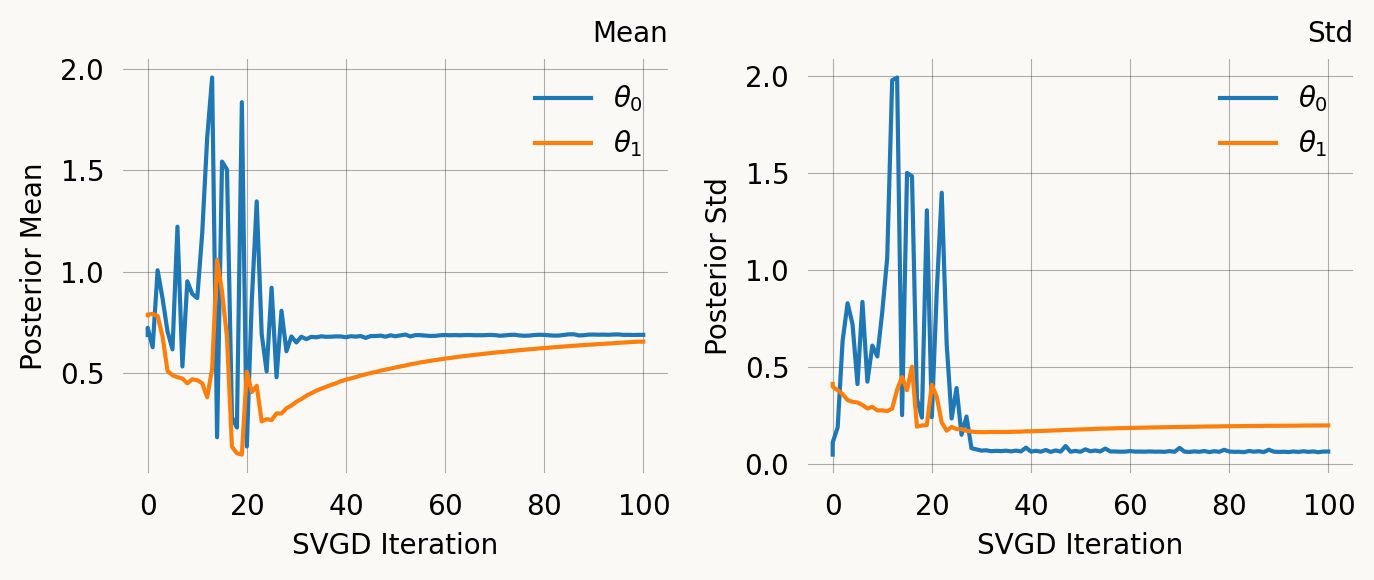

In [14]:
svgd.plot_convergence()

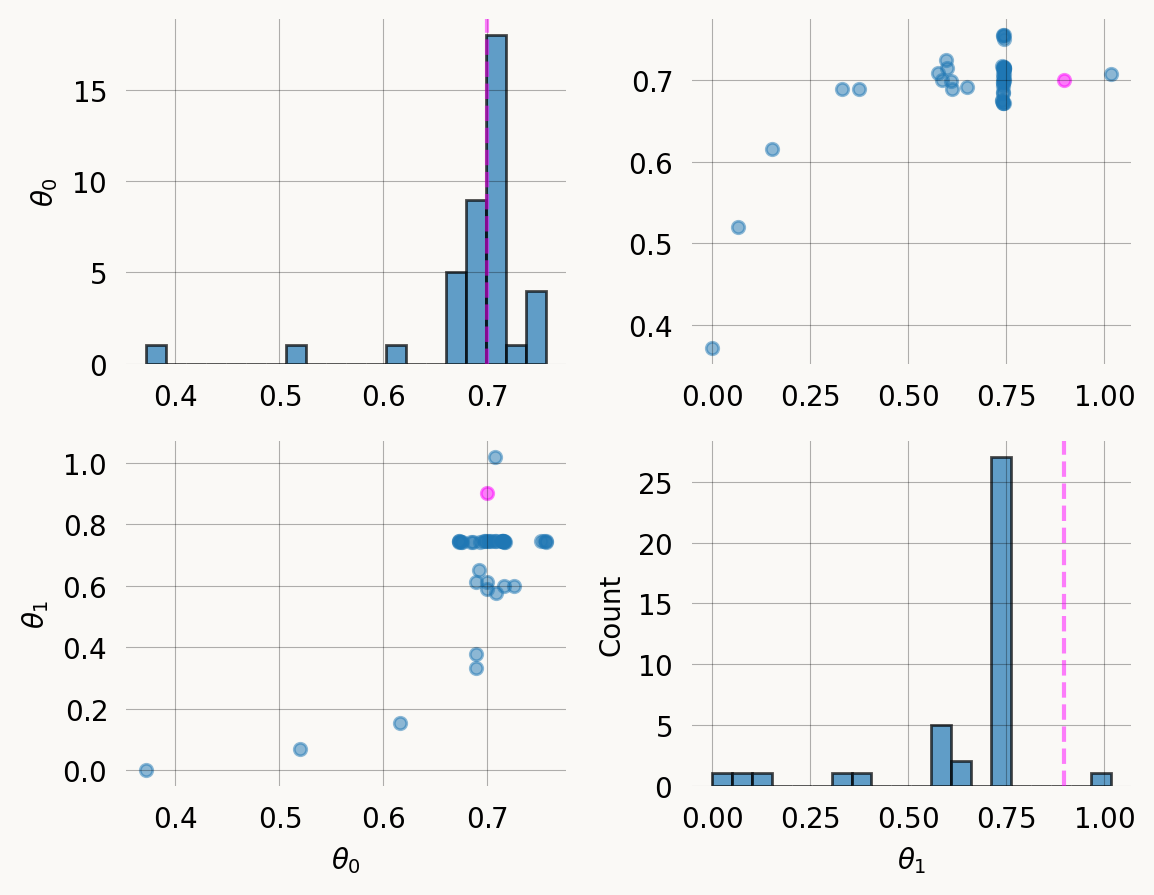

In [15]:
svgd.plot_pairwise(true_theta=true_theta)

## Multi-feature observations with rewards

For models where observations are reward-transformed (e.g. branch lengths contributing to different mutation categories in population genetics), method of moments can match moments per feature. Each feature has its own reward vector, and the combined system of equations constrains the parameters.

In [16]:
graph_1p = Graph(coalescent_1param)
true_theta_1p = [7]
graph_1p.update_weights(true_theta_1p)

# Create reward vectors — each row is a feature's reward across all vertices
states = graph_1p.states().T
rewards = states[:-1]  # one row per feature (e.g. singleton, doubleton, tripleton branch lengths)
print(f"Reward matrix shape: {rewards.shape}  (n_features={rewards.shape[0]}, n_vertices={rewards.shape[1]})")
print(f"Rewards:\n{rewards}")

Reward matrix shape: (3, 6)  (n_features=3, n_vertices=6)
Rewards:
[[0 4 2 0 1 0]
 [0 0 1 2 0 0]
 [0 0 0 0 1 0]]


Sample multi-feature observations (each SNP contributes to one feature)

In [17]:
n_obs = 10000
n_features = rewards.shape[0]
observed_data_2d = np.zeros((n_obs * n_features, n_features), dtype=float)
observed_data_2d[:] = np.nan
for i in range(n_features):
    observed_data_2d[(i*n_obs):((i+1)*n_obs), i] = graph_1p.sample(n_obs, rewards=rewards[i])
sparse_data = dense_to_sparse(observed_data_2d)

In [18]:
mom_multi = graph_1p.method_of_moments(
    sparse_data,
    rewards=rewards,
)
print(f"True theta:     {true_theta_1p}")
print(f"MoM estimate:   {mom_multi.theta}")
print(f"Converged:      {mom_multi.success}")
print(f"\nSample moments (n_features x nr_moments):\n{mom_multi.sample_moments}")
print(f"\nModel moments (n_features x nr_moments):\n{mom_multi.model_moments}")

True theta:     [7]
MoM estimate:   [6.97868763]
Converged:      True

Sample moments (n_features x nr_moments):
[[0.2843898  0.11597319]
 [0.15058287 0.07505271]
 [0.09552871 0.0272013 ]]

Model moments (n_features x nr_moments):
[[0.28658683 0.11863513]
 [0.14329342 0.06844334]
 [0.09552894 0.02737734]]


## Joint probability models

For joint probability graphs created using `graph.joint_prob_graph()`, observations are feature-count tuples (e.g., `[0, 1, 0, 0]`) rather than continuous times. The model outputs a probability table, not a PDF/PMF with moments, so standard moment matching does not apply.

The `probability_matching()` method handles this case by matching the empirical probability distribution to the model probability distribution:

$$
\hat{\theta}_{\text{PM}} = \arg\min_{\theta > 0} \left\| \mathbf{p}_{\text{model}}(\theta) - \hat{\mathbf{p}} \right\|^2
$$

where $\hat{\mathbf{p}}$ are the empirical proportions of each observation pattern. Standard errors are obtained via the delta method with the multinomial covariance:

$$
\text{Cov}(\hat{p}_i, \hat{p}_j) = \frac{\delta_{ij} p_i - p_i p_j}{n}
$$

In [19]:
from functools import partial
from itertools import combinations_with_replacement

all_pairs = partial(combinations_with_replacement, r=2)

# Build the coalescent base graph
nr_samples = 3

indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

base_graph = Graph(coalescent_1param)

# Create joint probability graph
mutation_rate = 1.0
joint_graph = base_graph.joint_prob_graph(
    indexer, tot_reward_limit=2, mutation_rate=mutation_rate
)
joint_graph.joint_prob_table()

,descendants_1,descendants_2,descendants_3,prob
t_vertex_index,,,,
4,0,0,0,0.166667
8,1,0,0,0.138889
11,0,1,0,0.055556
13,2,0,0,0.043981
14,1,1,0,0.032407
15,0,2,0,0.009259


Sample observations from the joint probability table:

In [20]:
true_theta = [7.0, mutation_rate]
joint_graph.update_weights(true_theta)

# Sample from the joint probability table
table = joint_graph.joint_prob_table()
p = table['prob'].to_numpy()
p = p / p.sum()
feature_cols = table.columns[:-1]

np.random.seed(42)
n_obs = 2000
sampled_rows = np.random.choice(len(table), size=n_obs, p=p)
observations = [tuple(int(x) for x in row) for row in table.iloc[sampled_rows][feature_cols].values]
print(f"Sampled {n_obs} observations, first 5: {observations[:5]}")

Sampled 2000 observations, first 5: [(0, 0, 0), (2, 0, 0), (1, 0, 0), (0, 0, 0), (0, 0, 0)]


Run `probability_matching()` with the mutation rate fixed:

In [21]:
pm = joint_graph.probability_matching(
    observations,
    fixed=[(1, mutation_rate)],
)

print(f"True theta:     {true_theta}")
print(f"PM estimate:    {pm.theta}")
print(f"Std error:      {pm.std}")
print(f"Converged:      {pm.success}")
print(f"Residual:       {pm.residual:.2e}")

ProbMatch: theta_dim=2, n_free=1, n_obs=2000, n_unique_obs=6
ProbMatch: initial guess (full theta) = [7.88046282 1.        ]
ProbMatch: converged — `gtol` termination condition is satisfied.
ProbMatch: theta = [7.00204262 1.        ]
ProbMatch: residual = 3.839769e-05
True theta:     [7.0, 1.0]
PM estimate:    [7.00204262 1.        ]
Std error:      [0.3560501 0.       ]
Converged:      True
Residual:       3.84e-05


The `ProbMatchResult` includes the empirical and model probabilities at the solution allowing posterior predictive check:

In [22]:
import pandas as pd
pd.DataFrame({
    'vertex_index': pm.unique_indices,
    'empirical_prob': pm.empirical_probs,
    'model_prob': pm.model_probs,
})

,vertex_index,empirical_prob,model_prob
0,4,0.6935,0.694502
1,8,0.1590,0.163940
2,11,0.0785,0.077149
3,13,0.0310,0.029057
4,14,0.0295,0.026782
5,15,0.0085,0.008570


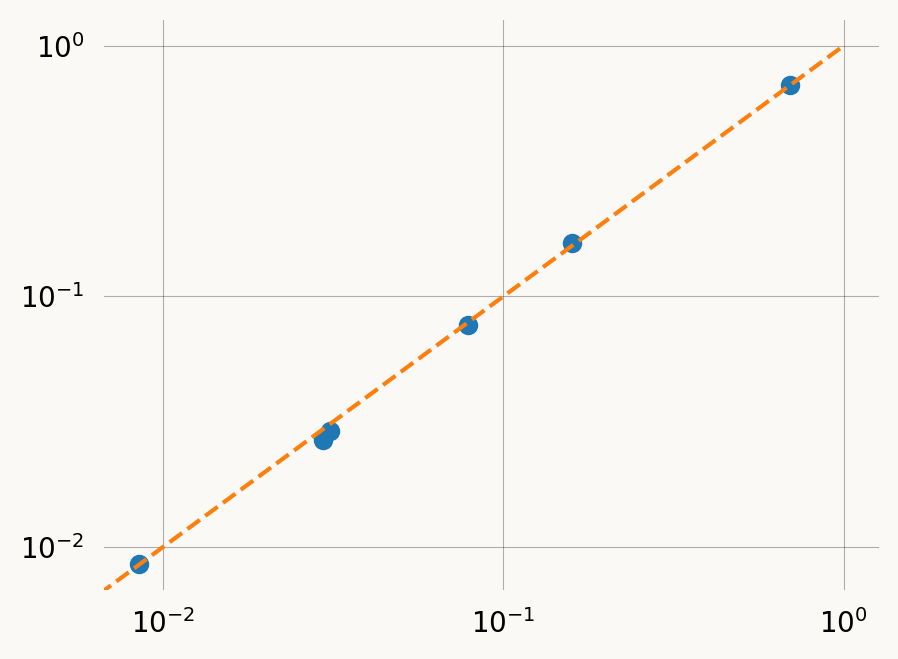

In [23]:
plt.plot([0, 1], [0, 1], ls='--', c='C1')
plt.scatter(pm.empirical_probs, pm.model_probs)
plt.xscale('log')
plt.yscale('log')

The `.prior` list can be passed directly to `graph.svgd()`, just like `MoMResult.prior`:

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.8969     6.8598     0.2025     6.3339       7.2565      
1          Yes        1.0000     NA         NA         NA           NA          

Particles: 40, Iterations: 100


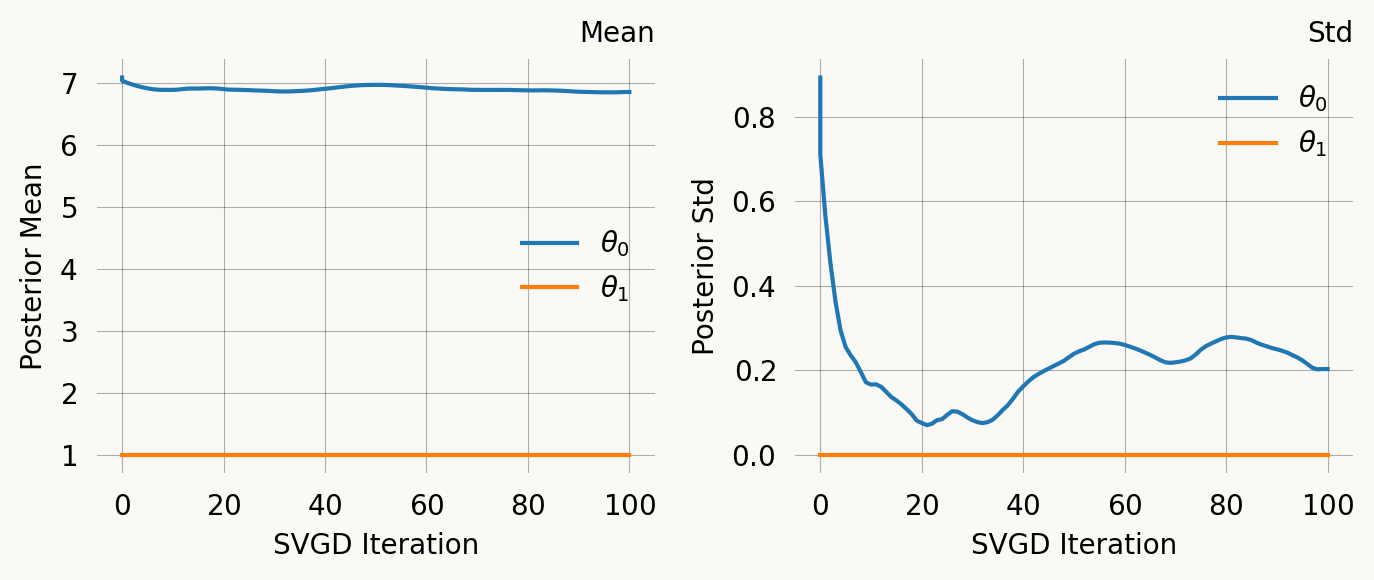

In [24]:
svgd_jp = joint_graph.svgd(
    observations,
    prior=pm.prior,
    fixed=[(1, mutation_rate)],
    optimizer=Adam(0.25),
)
svgd_jp.summary()
svgd_jp.plot_convergence()